<a href="https://colab.research.google.com/github/kaythkevellyn/Kayth-Kevellyn-da-Silva-Oliveira---202502349114/blob/main/Aula_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# Criação do Dataset
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]

datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)
nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

df.to_csv("vendas_livraria.csv", index=False)

df.head()

,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [ ]:
# Exploração Inicial
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
📋 INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

📊 TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

🔍 VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

📈 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [ ]:
# Análise de Vendas

# 1. Total faturado
total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

💰 Faturamento Total: R$ 7,538.40

📦 Faturamento por Categoria:
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: object

🏆 Ranking de Vendedores:
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: object

📚 Top 3 Produtos (qtd vendida):
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

🗺️  Ticket Médio por Região:
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: object


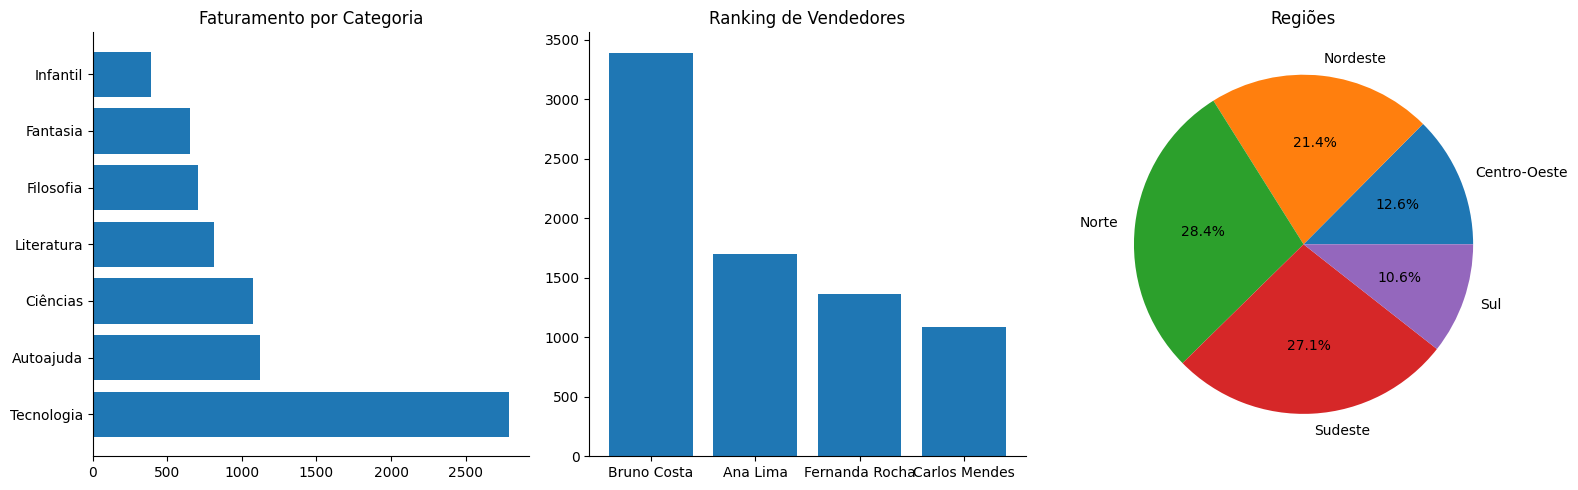

In [ ]:
# Visualizações
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1
axes[0].barh(cat_fat.index, cat_fat.values)
axes[0].set_title("Faturamento por Categoria")

# Gráfico 2
axes[1].bar(vend_rank.index, vend_rank.values)
axes[1].set_title("Ranking de Vendedores")

# Gráfico 3
reg_total = df.groupby("regiao")["total_venda"].sum()
axes[2].pie(reg_total, labels=reg_total.index, autopct="%1.1f%%")
axes[2].set_title("Regiões")

plt.tight_layout()
plt.show()

In [ ]:
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month

faturamento_mes = df.groupby("mes")["total_venda"].sum()
print(faturamento_mes)

mes
1    1251.4
2    1281.1
3    1505.6
4    1284.4
5    1263.5
6     952.4
Name: total_venda, dtype: float64


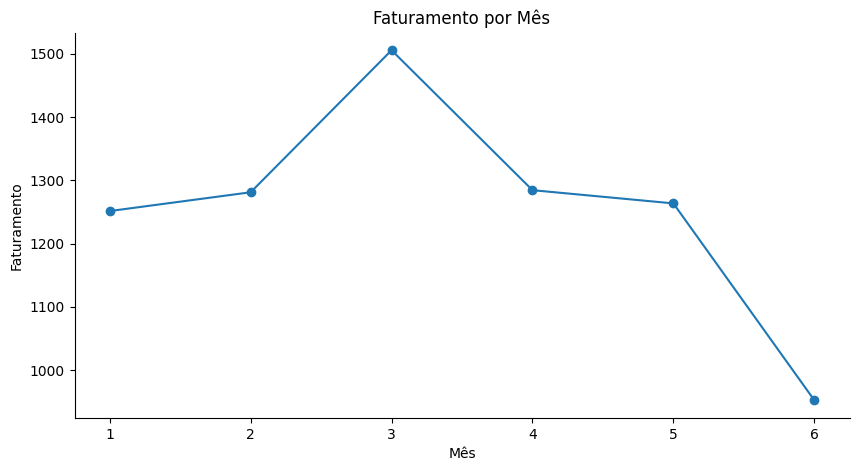

In [ ]:
faturamento_mes.plot(kind="line", marker="o")
plt.title("Faturamento por Mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.show()

In [ ]:
ticket_medio = df.groupby("vendedor")["total_venda"].mean()
print(ticket_medio.sort_values(ascending=False))

vendedor
Bruno Costa       161.566667
Fernanda Rocha    151.233333
Ana Lima          141.733333
Carlos Mendes     135.450000
Name: total_venda, dtype: float64


In [ ]:
altas = df[df["total_venda"] > 200]
print(altas.groupby("categoria")["total_venda"].count())

categoria
Autoajuda     1
Ciências      1
Fantasia      1
Tecnologia    5
Name: total_venda, dtype: int64


In [ ]:
df.loc[0:4, "preco_unit"] = None

print("Valores nulos:")
print(df.isnull().sum())

df["preco_unit"] = df["preco_unit"].fillna(df["preco_unit"].mean())

print("\nApós tratamento:")
print(df.isnull().sum())

Valores nulos:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     5
vendedor       0
regiao         0
total_venda    0
mes            0
dtype: int64

Após tratamento:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
mes            0
dtype: int64
